In [65]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from typing import TypedDict, Annotated
from pydantic import Field
from dotenv import load_dotenv
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph.message import add_messages
import sqlite3
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.agents import create_agent
from langgraph.prebuilt import ToolNode,tool_node


In [81]:
import os
load_dotenv()
os.environ["LANGCHAIN_PROJECT"]="tool using langgraph"

llm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [82]:


search_tool=DuckDuckGoSearchRun()


@tool
def calculator(first_num:float,second_num:float,operation:str)->dict:
    """
    perform basic arithematic operations like addition ubstraction,multiplication,dividion
    """
    try:
        if operation=="add":
            result=first_num+second_num
        elif operation=="sub":
            result=first_num-second_num
        elif operation=="mul":
            result=first_num*second_num
        elif operation=="div":
            result=first_num/second_num
        else:
            return {"error":f"unsupported operation{operation}"}
        return {"first_num":first_num,"second_num":second_num,"operation":operation,"result":result}
    except Exception as e:
        return {"error":f"the error is {e}"}

  

In [83]:
tools=[calculator,search_tool]

In [84]:
llm_with_tools=llm.bind_tools(tools)

In [85]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [86]:
def chat_node(state:ChatState):
    "llm node that may answer or request a tool call"
    message=state["messages"]
    response=llm_with_tools.invoke(message)
    return {"messages":[response]}

In [87]:
tool_node=ToolNode(tools)

In [88]:
from langgraph.prebuilt import tools_condition

In [89]:
graph=StateGraph(ChatState)

graph.add_node("chatnode",chat_node)
graph.add_node("tools",tool_node)


graph.add_edge(START,"chatnode")
graph.add_conditional_edges("chatnode",tools_condition)
graph.add_edge("tools","chatnode")


chatbot=graph.compile()

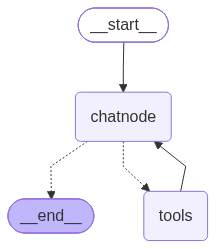

In [90]:
chatbot

In [91]:
out=chatbot.invoke({"messages":[HumanMessage(content="who is cjp founder?")]})



In [92]:
print(out["messages"][-1].content)

The Cockroach Janata Party (CJP) was founded on 16 May 2026 by **Abhijeet Dipke**, a political‑communications strategist and activist (who was also a student at Boston University at the time).


In [93]:
out=chatbot.invoke({"messages":[HumanMessage(content="what is 2* 3 ?")]})



In [94]:
print(out["messages"][-1].content)

2 × 3 = 6.


In [95]:
chatbot.invoke({"messages":[HumanMessage(content="who is cjp founder and what is 2*3?")]})["messages"][-1].content

'**CJP founder**  \nThe Cockroach Janta Party (CJP) was founded by **Abhijeet\u202fDipke** (sometimes reported as Abhijit\u202fDipke). He launched the party to address issues such as government exam paper leaks, election‑commission accountability, and broader democratic concerns in India.\n\n**2\u202f×\u202f3 = 6**'